### Exploratory data analysis (EDA) 

In [1]:
import pandas as pd

train_df = pd.read_csv("UNSW_NB15_training-set.csv")
test_df = pd.read_csv("UNSW_NB15_testing-set.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (175341, 45)
Test shape: (82332, 45)


### Explination: 
output shape = (rows, columns)

#### For train_df:
This output shows the dimensions of the datasets
For traininng set we have 175341 network traffic records and 45 number of features (variables)

=> This dataset will be used to train the machine learning model.
#### For test_df:
We have 82332 unseen observations and 45 same features as the training set

=> This dataset will be used to evaluate the model’s performance.


In [2]:
train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [3]:
test_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


Combien de valeurs non-null et s’il y a des missing values

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

All columns have 175,341 non-null values which there are NO missing values in the training dataset so no imputation is required 

Numerical features: 30 int64 columns and float64 columns NB: These features will likely need Scaling / normalization

There are 4 categorical columns:

- proto → protocol type (TCP, UDP, ICMP, …)
- service → network service (HTTP, FTP, DNS, …)
- state → connection state
- attack_cat → attack category (Normal, DoS, Exploits, etc.)

These must be encoded (one-hot encoding or label encoding)

In [5]:
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = train_df.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

Numerical features: 41
Categorical features: 4


In [6]:
train_df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [7]:
# counts how many missing values exist per column
train_df.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

All 45 features have zero missing values
There are no NaN or null entries in the training dataset


In [8]:
# counts the number of missing values per column
(train_df.isnull().sum() / len(train_df)) * 100

id                   0.0
dur                  0.0
proto                0.0
service              0.0
state                0.0
spkts                0.0
dpkts                0.0
sbytes               0.0
dbytes               0.0
rate                 0.0
sttl                 0.0
dttl                 0.0
sload                0.0
dload                0.0
sloss                0.0
dloss                0.0
sinpkt               0.0
dinpkt               0.0
sjit                 0.0
djit                 0.0
swin                 0.0
stcpb                0.0
dtcpb                0.0
dwin                 0.0
tcprtt               0.0
synack               0.0
ackdat               0.0
smean                0.0
dmean                0.0
trans_depth          0.0
response_body_len    0.0
ct_srv_src           0.0
ct_state_ttl         0.0
ct_dst_ltm           0.0
ct_src_dport_ltm     0.0
ct_dst_sport_ltm     0.0
ct_dst_src_ltm       0.0
is_ftp_login         0.0
ct_ftp_cmd           0.0
ct_flw_http_mthd     0.0


In [9]:
#counts the number of unique values in each column
train_df.nunique().sort_values()

label                     2
is_sm_ips_ports           2
is_ftp_login              4
ct_ftp_cmd                4
ct_state_ttl              5
dttl                      6
dwin                      7
state                     9
attack_cat               10
trans_depth              11
sttl                     11
ct_flw_http_mthd         11
service                  13
swin                     13
ct_dst_sport_ltm         32
ct_src_dport_ltm         47
ct_src_ltm               50
ct_dst_ltm               50
ct_srv_src               52
ct_srv_dst               52
ct_dst_src_ltm           54
proto                   133
dloss                   370
sloss                   409
dpkts                   443
spkts                   480
dmean                  1328
smean                  1357
response_body_len      2386
dbytes                 6660
sbytes                 7214
ackdat                37708
synack                40142
tcprtt                43319
dur                   74039
dinpkt              

- Binary features : label and is_sm_ips_ports (do not need encoding)
- Low-cardinality discrete features (3-10) ex: attack_cat has 10 distinct attack types => need encoding
- Moderate-cardinality categorical features ex: proto has 133 unique values => Require careful encoding choice
- etc 

In [10]:
train_df["label"].value_counts()
train_df["label"].value_counts(normalize=True)
#Normalize= true to get the percentage of each class in the target variable

1    0.680622
0    0.319378
Name: label, dtype: float64

- 1 (Attack): 68.06% of the dataset
- 0 (Normal): 31.94% of the dataset
Note: our data is imbalanced it can impact the model evaluation

In [11]:
train_df["attack_cat"].value_counts()
train_df["attack_cat"].value_counts(normalize=True)

Normal            0.319378
Generic           0.228127
Exploits          0.190446
Fuzzers           0.103706
DoS               0.069944
Reconnaissance    0.059832
Analysis          0.011406
Backdoor          0.009958
Shellcode         0.006462
Worms             0.000741
Name: attack_cat, dtype: float64

In [12]:
set(train_df.columns) == set(test_df.columns)

True

This checks whether the train and test datasets have exactly the same columns, regardless of order.

In [ ]:
#pip install --upgrade pandas

In [62]:
correlation_matrix = train_df.corr()
correlation_matrix

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
id,1.000000,0.006587,-0.068827,-0.126316,0.001104,-0.080283,0.364575,0.615508,-0.049604,0.143649,...,0.536544,0.601158,0.539093,-0.037636,-0.037636,-0.028287,0.425396,0.480899,0.033142,0.727173
dur,0.006587,1.000000,0.254559,0.181182,0.199731,0.144134,-0.120966,0.012196,0.044159,-0.081749,...,-0.094091,-0.093923,-0.101760,0.020641,0.020641,0.024743,-0.080871,-0.115336,0.035370,0.036175
spkts,-0.068827,0.254559,1.000000,0.390067,0.963791,0.206609,-0.076358,-0.102723,0.068246,-0.051646,...,-0.068373,-0.072484,-0.077553,0.009951,0.009951,0.006084,-0.061584,-0.069598,-0.017770,-0.052178
dpkts,-0.126316,0.181182,0.390067,1.000000,0.188476,0.971907,-0.098202,-0.192580,0.053861,-0.066710,...,-0.086695,-0.094267,-0.094085,0.013491,0.013491,0.047974,-0.075190,-0.078342,-0.021765,-0.118591
sbytes,0.001104,0.199731,0.963791,0.188476,1.000000,0.009926,-0.028468,-0.020860,0.063009,-0.018322,...,-0.026490,-0.027281,-0.032061,-0.004515,-0.004515,-0.002185,-0.027479,-0.034553,-0.006367,0.018576
dbytes,-0.080283,0.144134,0.206609,0.971907,0.009926,1.000000,-0.059475,-0.135515,0.023559,-0.040430,...,-0.052135,-0.056901,-0.054633,-0.010460,-0.010460,0.051403,-0.045594,-0.044531,-0.013147,-0.076871
rate,0.364575,-0.120966,-0.076358,-0.098202,-0.028468,-0.059475,1.000000,0.407572,-0.414546,0.602492,...,0.353589,0.390721,0.383094,-0.068140,-0.068140,-0.109297,0.310876,0.362883,-0.072948,0.337979
sttl,0.615508,0.012196,-0.102723,-0.192580,-0.020860,-0.135515,0.407572,1.000000,-0.032823,0.276475,...,0.344104,0.379930,0.404346,-0.124157,-0.124157,-0.112833,0.273252,0.340678,-0.220429,0.692741
dttl,-0.049604,0.044159,0.068246,0.053861,0.063009,0.023559,-0.414546,-0.032823,1.000000,-0.280427,...,-0.366308,-0.389429,-0.403465,0.107208,0.107208,0.223652,-0.365404,-0.431188,-0.091137,0.095049
sload,0.143649,-0.081749,-0.051646,-0.066710,-0.018322,-0.040430,0.602492,0.276475,-0.280427,1.000000,...,0.100118,0.082462,0.155030,-0.046194,-0.046194,-0.073920,0.084412,0.141168,-0.049327,0.182870


### Distribution Plots

#### Label distribution (Binary classification)

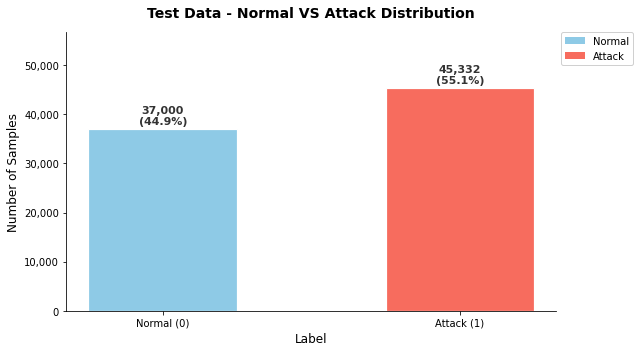

In [63]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

counts = test_df["label"].value_counts().sort_index()  # ← test_df
labels_names = ["Normal (0)", "Attack (1)"]
colors = ["#8ecae6", "#f76c5e"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    labels_names,
    counts.values,
    color=colors,
    width=0.5,
    edgecolor="white",
    linewidth=1.2
)

for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,  # ← réduit un peu car test_df est plus petit
        f"{count:,}\n({count / counts.sum() * 100:.1f}%)",
        ha="center", va="bottom",
        fontsize=11, fontweight="bold", color="#333333"
    )

ax.set_title("Test Data - Normal VS Attack Distribution", fontsize=14, fontweight="bold", pad=15)  # ← titre mis à jour
ax.set_xlabel("Label", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)

ax.set_ylim(0, counts.max() * 1.25)
ax.margins(y=0)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

legend_elements = [
    Patch(facecolor="#8ecae6", label="Normal"),
    Patch(facecolor="#f76c5e", label="Attack")
]
ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    framealpha=0.9
)

plt.tight_layout()
plt.show()

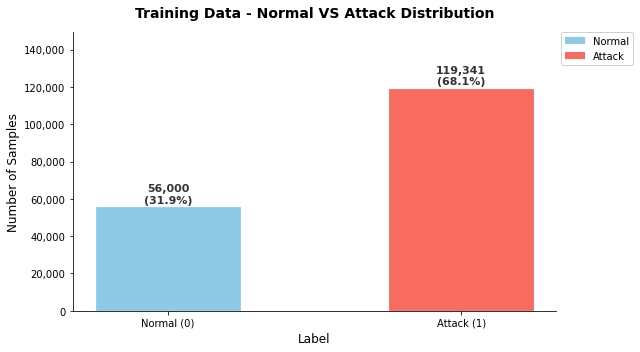

In [64]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

counts = train_df["label"].value_counts().sort_index()
labels_names = ["Normal (0)", "Attack (1)"]
colors = ["#8ecae6", "#f76c5e"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    labels_names,
    counts.values,
    color=colors,
    width=0.5,
    edgecolor="white",
    linewidth=1.2
)

for bar, count in zip(bars, counts.values):
    percentage = count / counts.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center", 
        va="bottom",
        fontsize=11, 
        fontweight="bold", 
        color="#333333"
    )

ax.set_title(
    "Training Data - Normal VS Attack Distribution", 
    fontsize=14, 
    fontweight="bold", 
    pad=15
)
ax.set_xlabel("Label", fontsize=12)
ax.set_ylabel("Number of Samples", fontsize=12)

ax.set_ylim(0, counts.max() * 1.25)
ax.margins(y=0)

ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

legend_elements = [
    Patch(facecolor="#8ecae6", label="Normal"),
    Patch(facecolor="#f76c5e", label="Attack")
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0,
    framealpha=0.9
)

plt.tight_layout()
plt.show()

Interpretation (for report)

The dataset is imbalanced

Class 1 (Attack) dominates

Class 0 (Normal) is underrepresented

This imbalance can bias classifiers toward predicting attacks

This justifies:

Using class_weight

Using SMOTE

Using Recall / F1-score instead of accuracy

#### Attack category distribution (Multi-class)

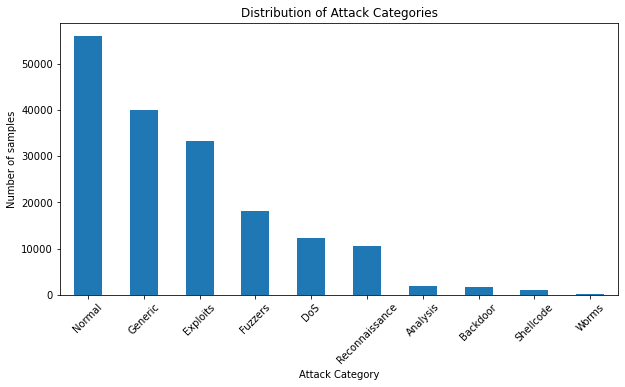

In [65]:
train_df["attack_cat"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    title="Distribution of Attack Categories",
    xlabel="Attack Category",
    ylabel="Number of samples",
    rot=45
)
plt.show()

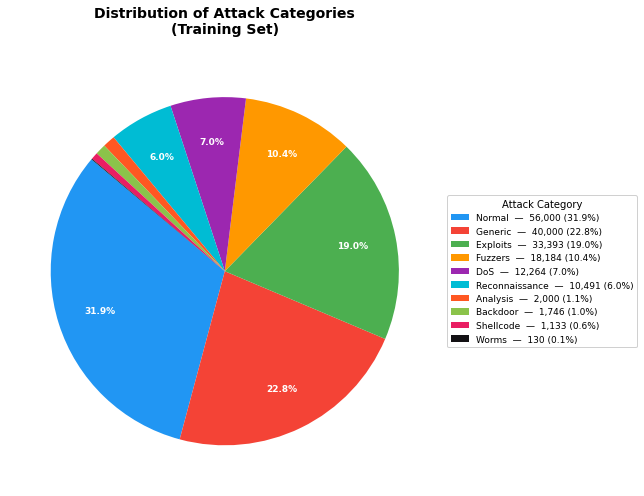

In [66]:
import matplotlib.pyplot as plt

counts = train_df["attack_cat"].value_counts()

colors = [
    "#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0",
    "#00BCD4", "#FF5722", "#8BC34A", "#E91E63", "#131114"
]

# Explode légère sur la plus petite part (Worms) pour la lisibilité
explode = [0.03] * len(counts)

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,          
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 1.5 else "",  # masque les % trop petits
    startangle=140,
    #explode=explode,
    pctdistance=0.75,
    #wedgeprops=dict(edgecolor="white", linewidth=1.5)
)

# Style des pourcentages
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

# Légende avec count + % à droite
legend_labels = [
    f"{cat}  —  {count:,} ({count/counts.sum()*100:.1f}%)"
    for cat, count in zip(counts.index, counts.values)
]
ax.legend(
    wedges,
    legend_labels,
    title="Attack Category",
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    framealpha=0.9
)

ax.set_title("Distribution of Attack Categories\n(Training Set)", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

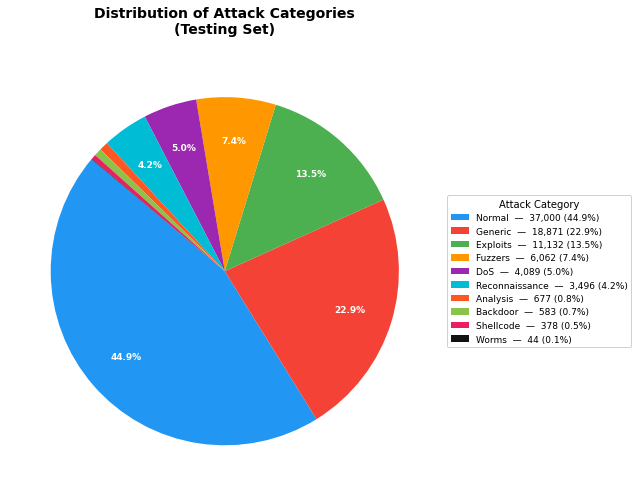

In [67]:
import matplotlib.pyplot as plt

counts = test_df["attack_cat"].value_counts()  # ← test_df

colors = [
    "#2196F3", "#F44336", "#4CAF50", "#FF9800", "#9C27B0",
    "#00BCD4", "#FF5722", "#8BC34A", "#E91E63", "#131114"
]

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 1.5 else "",
    startangle=140,
    pctdistance=0.75,
)

for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

legend_labels = [
    f"{cat}  —  {count:,} ({count/counts.sum()*100:.1f}%)"
    for cat, count in zip(counts.index, counts.values)
]
ax.legend(
    wedges,
    legend_labels,
    title="Attack Category",
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    framealpha=0.9
)

ax.set_title("Distribution of Attack Categories\n(Testing Set)", fontsize=14, fontweight="bold", pad=20)  # ← Testing Set + \n corrigé

plt.tight_layout()
plt.show()

Interpretation

Some attack categories dominate (e.g., Normal, Generic, Exploits)

Others are rare (e.g., Worms, Shellcode)

This makes multi-class classification harder

Reinforces the need for:

Oversampling

Cascading or hierarchical classification

Class-weighted models

### Correlation Heatmap (Numeric Features Only)

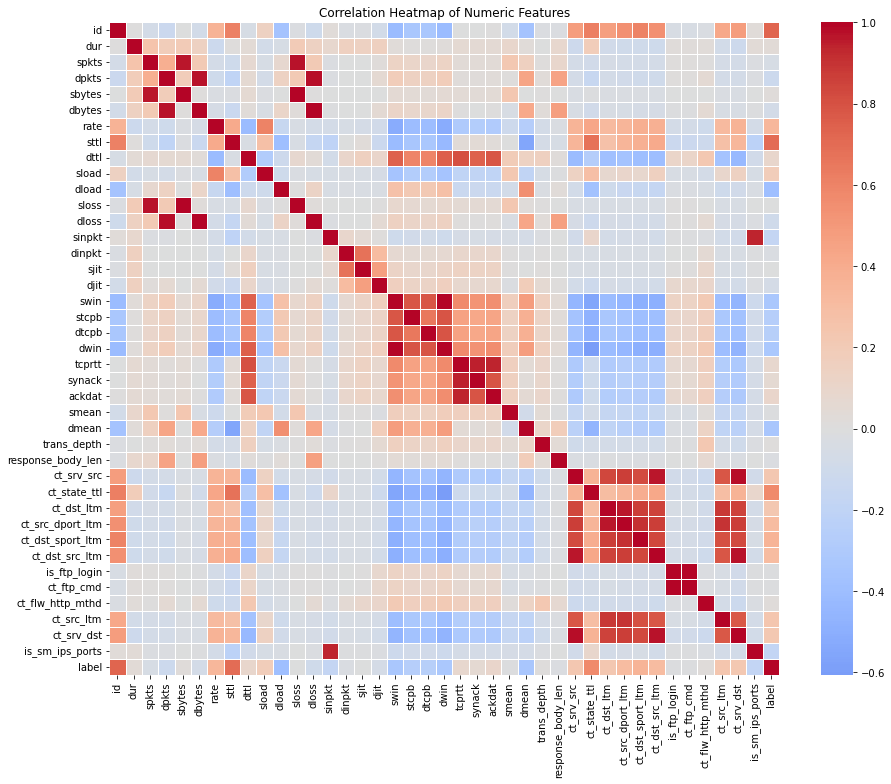

In [68]:
import seaborn as sns

# Select numeric features only
numeric_df = train_df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(15,12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, linewidths=0.5 )
plt.title("Correlation Heatmap of Numeric Features")
plt.show()


### Feature Importance (Tree-Based Model)

In [69]:
X = train_df.drop(columns=["label", "attack_cat", "id"])
y = train_df["label"]

# One-hot encode categorical features
X = pd.get_dummies(X, columns=["proto", "service", "state"], drop_first=True)


In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X, y)


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

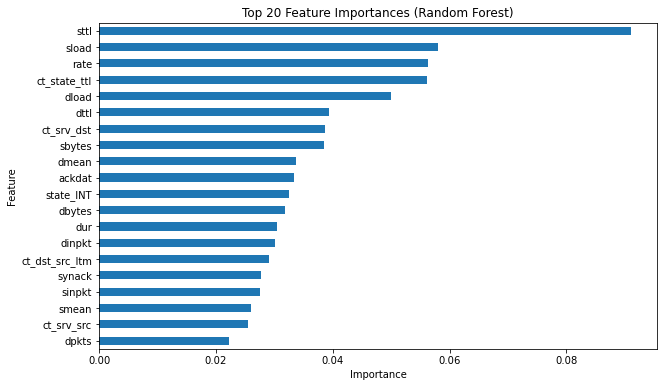

In [71]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(20)

top_features.plot(kind="barh", figsize=(10,6))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()


### Correct Preprocessing Pipeline

#### Separate features

In [72]:
X = train_df.drop(columns=["label", "attack_cat"])
y = train_df["label"]

categorical_cols = ["proto", "service", "state"]
numerical_cols = X.columns.difference(categorical_cols)

#### Train / Test split (NO DATA LEAKAGE)

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

#### Encode categorical features

In [74]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

#### Scale numerical features

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num  = scaler.transform(X_test[numerical_cols])

#### Combine features

In [76]:
import numpy as np

X_train_final = np.hstack([X_train_num, X_train_cat])
X_test_final  = np.hstack([X_test_num, X_test_cat])

print(X_train_final.shape)
print(X_test_final.shape)

(122738, 193)
(52603, 193)


#### Handle class imbalance

In [57]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)


In [ ]:
%pip install seaborn

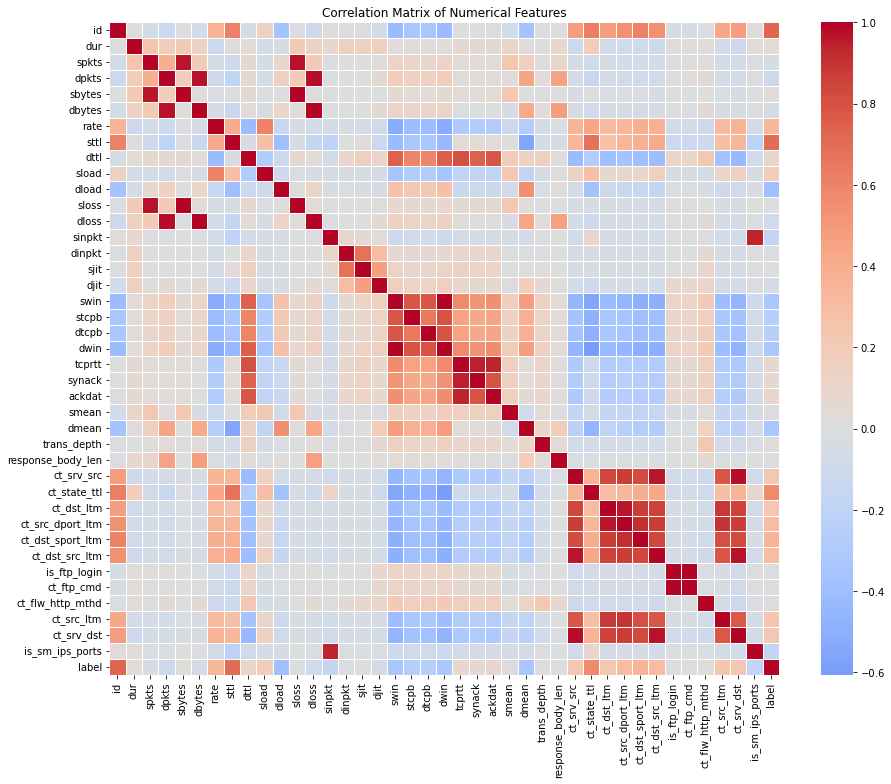

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,12))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

- Red: These features may be redundant (strong positive)
- Blue: inverse relationship (strong negative)
- Light: the relationship is not linear

clusters of highly correlated features: 
from swin to ackdat
from ct_srv_src to ct_dst_src_ltm
ct_srv_ltm

sinpkt --> is_sm_ips_ports
ct_srv_src --> ct_srv_dst
label --> id /sttl/ct_state_ttl 

The correlation heatmap reveals strong positive correlations among several numerical features, particularly those related to packet counts, byte volumes, and traffic load. These clusters indicate potential redundancy and multicollinearity within the dataset. The target variable (label) shows varying degrees of correlation with different features, suggesting their potential importance for intrusion detection. The correlation analysis provides valuable insight for feature selection and model design

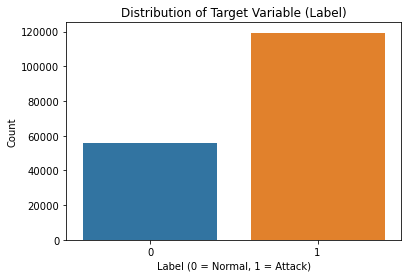

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="label", data=train_df)
plt.title("Distribution of Target Variable (Label)")
plt.xlabel("Label (0 = Normal, 1 = Attack)")
plt.ylabel("Count")
plt.show()

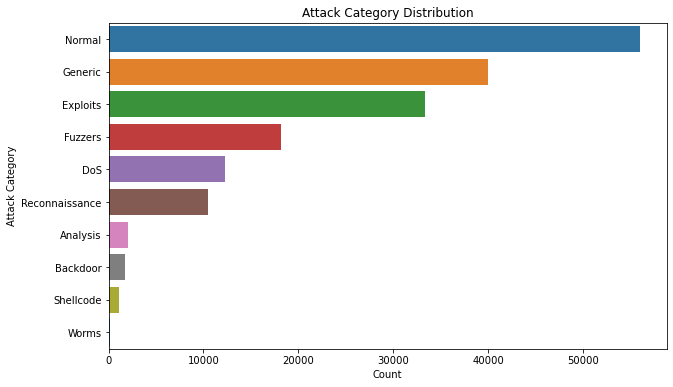

In [79]:
plt.figure(figsize=(10,6))
sns.countplot(y="attack_cat", data=train_df, order=train_df["attack_cat"].value_counts().index)
plt.title("Attack Category Distribution")
plt.xlabel("Count")
plt.ylabel("Attack Category")
plt.show()

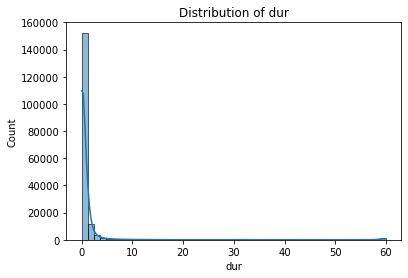

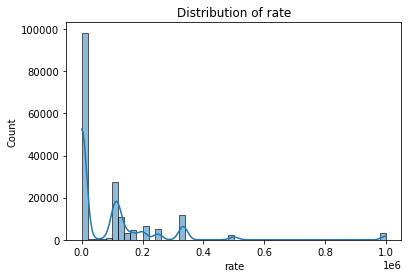

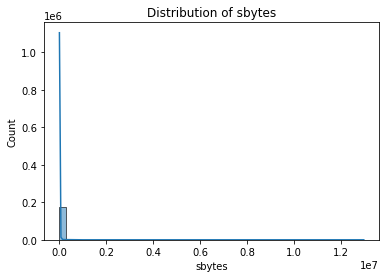

In [80]:
num_features = ["dur", "rate", "sbytes"]

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.histplot(train_df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

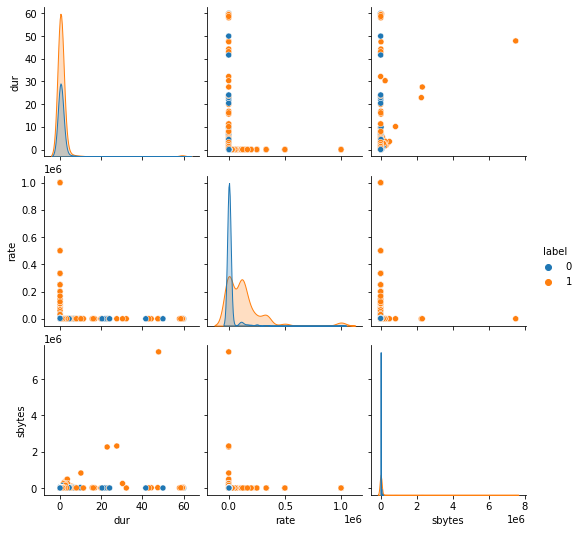

In [81]:
sample_df = train_df.sample(2000, random_state=42)

sns.pairplot(sample_df, vars=["dur", "rate", "sbytes"], hue="label")
plt.show()

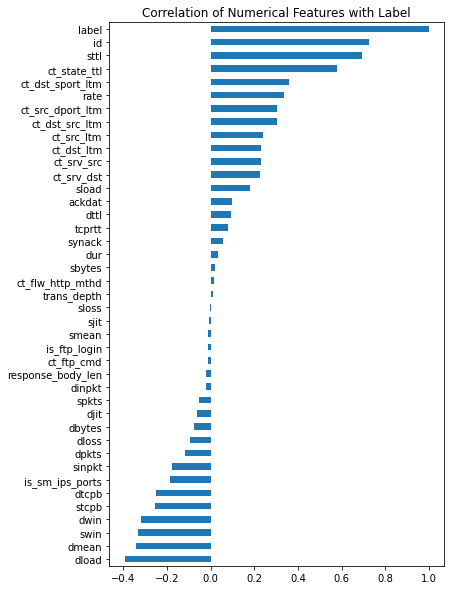

In [82]:
corr_with_label = correlation_matrix["label"].sort_values()

plt.figure(figsize=(6,10))
corr_with_label.plot(kind="barh")
plt.title("Correlation of Numerical Features with Label")
plt.show()


### PREPROCESSING PIPELINE

In [83]:
# Drop non-informative columns
train_df = train_df.drop(columns=["id"])
test_df  = test_df.drop(columns=["id"])

Separate features and target

In [84]:
X_train = train_df.drop(columns=["label", "attack_cat"])
y_train = train_df["label"]

X_test  = test_df.drop(columns=["label", "attack_cat"])
y_test  = test_df["label"]

In [85]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols   = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)


Categorical: Index(['proto', 'service', 'state'], dtype='object')
Numerical: Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl',
       'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit',
       'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
       'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
       'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports'],
      dtype='object')


In [86]:
%pip install scikit-learn

  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
daal4py 2021.5.0 requires daal==2021.4.0, which is not installed.
numba 0.55.1 requires numpy<1.22,>=1.18, but you have numpy 1.22.4 which is incompatible.


In [87]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

TypeError: __init__() got an unexpected keyword argument 'sparse_output'

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num  = scaler.transform(X_test[numerical_cols])


In [ ]:
import numpy as np

X_train_final = np.hstack((X_train_num, X_train_cat))
X_test_final  = np.hstack((X_test_num, X_test_cat))


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), class_weights))
class_weights


In [ ]:
%pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)


In [ ]:
print(X_train_final.shape)
print(X_test_final.shape)


Your pipeline should be:

Drop attack_cat for binary task

Separate:

Numerical features → StandardScaler

Categorical features → OneHotEncoder

Handle imbalance:

class_weight

SMOTE (train only)

📌 Clearly state:

“All transformations are fitted on training data only to avoid data leakage.”

Phase 3 – Modeling 

Phase 4 – Evaluation

Phase 5 – Raspberry Pi Deployment